In [49]:
##Data Cleaning
userlib <- file.path(Sys.getenv("USERPROFILE"), "Documents", "R", "win-library",
                     paste0(R.version$major, ".", R.version$minor))
dir.create(userlib, recursive = TRUE, showWarnings = FALSE)
.libPaths(c(userlib, .libPaths()))
options(repos = c(CRAN = "https://cloud.r-project.org"))
install.packages("gapminder", type = "binary", dependencies = TRUE)
install.packages("naniar")
install.packages("lmtest")
install.packages("pROC")
install.packages(c("randomForest", "caret", "janitor"))
install.packages("glmnet")
##make sure to run this before using the library 
install.packages(c("tidyverse","rstatix","ggpubr"))
install.packages("gtExtras", repos = c('https://jthomasmock.r-universe.dev', 'https://cloud.r-project.org'))
library(ggpubr)
library(tidyverse)
library(gapminder)
install.packages("dplyr")
library(dplyr)
library(rstatix)
install.packages("kSamples")
library(kSamples)
library(naniar)
library(gtExtras)
library(lmtest)
library(pROC)
library(randomForest)
library(caret)
install.packages("rpart")        # only once
install.packages("rpart.plot")   # optional, for nicer plots
library(rpart)
library(rpart.plot)
library(glmnet)
install.packages("leaps")
library(leaps)

#this is the code to load the dataset

Warning message:
"package 'gapminder' is in use and will not be installed"
Warning message:
"package 'naniar' is in use and will not be installed"
Warning message:
"package 'lmtest' is in use and will not be installed"
Warning message:
"package 'pROC' is in use and will not be installed"
Warning message:
"packages 'randomForest', 'caret' are in use and will not be installed"
Installing package into 'C:/Users/admin/Documents/R/win-library/4.5.2'
(as 'lib' is unspecified)



package 'janitor' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\admin\AppData\Local\Temp\RtmpKW7QyL\downloaded_packages


Warning message:
"package 'glmnet' is in use and will not be installed"
Warning message:
"packages 'tidyverse', 'rstatix', 'ggpubr' are in use and will not be installed"
Warning message:
"package 'gtExtras' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'kSamples' is in use and will not be installed"
Warning message:
"package 'rpart' is in use and will not be installed"
Warning message:
"package 'rpart.plot' is in use and will not be installed"
Warning message:
"package 'leaps' is in use and will not be installed"


In [50]:
df=read.csv("C:/Users/admin/Downloads/train_u6lujuX_CVtuZ9i.csv")
head(df)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate,No,5849,0,NA,360,1,Urban,Y
2,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
3,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
4,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y


In [51]:
num_rows <- nrow(df)
head(df[, 1:5])
print(paste("Number of rows:", num_rows))
num_columns <- ncol(df)
names(df)
print(paste("Number of columns:", num_columns))
cols <- c("Loan_ID","Gender","Dependents","Education","Self_Employed","ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History","Property_Area","Loan_Status")
df[cols] <- lapply(df[cols], function(x) {
  x[x == 0] <- NA
  x
})

,Loan_ID,Gender,Married,Dependents,Education
,<chr>,<chr>,<chr>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate
2,LP001003,Male,Yes,1,Graduate
3,LP001005,Male,Yes,0,Graduate
4,LP001006,Male,Yes,0,Not Graduate
5,LP001008,Male,No,0,Graduate
6,LP001011,Male,Yes,2,Graduate


[1] "Number of rows: 614"


[1] "Loan_ID"           "Gender"            "Married"          
 [4] "Dependents"        "Education"         "Self_Employed"    
 [7] "ApplicantIncome"   "CoapplicantIncome" "LoanAmount"       
[10] "Loan_Amount_Term"  "Credit_History"    "Property_Area"    
[13] "Loan_Status"

[1] "Number of columns: 13"


In [4]:
fit_full  <- lm(LoanAmount ~ ., data = df1)
fit_null  <- lm(LoanAmount ~ 1, data = df1)
AIC(fit_full)
logLik(fit_full)

[1] -Inf

'log Lik.' Inf (df=112)

In [5]:
n <- nrow(df1)
fit_full <- lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married , data = df1)
fit_bic <- step(fit_full, direction = "both", k = log(n), trace = 0)
summary(fit_bic)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


In [6]:
fit_full  <- lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married , data = df1)      # all predictors
fit_null  <- lm(LoanAmount ~ 1, data = df1)      # intercept only
# Forward selection (from null up to full) by AIC
fit_fwd <- step(fit_null,scope = formula(fit_full),direction = "forward",trace = 0)
# Backward selection (from full down) by AIC
fit_bwd <- step(fit_full, direction = "backward", trace = 0)
# Both directions (stepwise)
fit_both <- step(fit_full, direction = "both", trace = 0)
summary(fit_both)
formula(fit_both)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


LoanAmount ~ ApplicantIncome

In [7]:
n <- nrow(df1)
fit_full <- lm( LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = df1)
fit_bic <- step(fit_full, direction = "both", k = log(n), trace = 0)
summary(fit_bic)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


In [102]:
regfit <- regsubsets(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = df, nvmax = ncol(df) - 1)
s <- summary(regfit)
s$cp              # Mallows Cp for each best model size
which.min(s$cp)   # model size with smallest Cp
s$which[which.min(s$cp), ]  # which variables are in that model

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"1  linear dependencies found"


Reordering variables and trying again:


[1] 3.71337376 1.54104291 0.07031865 0.86915119 2.59331072 4.44924300 6.32058390
[8] 8.00000000

[1] 3

(Intercept)    GenderFemale      GenderMale     Dependents1     Dependents2 
           TRUE           FALSE            TRUE           FALSE           FALSE 
   Dependents3+ ApplicantIncome  Credit_History       MarriedNo      MarriedYes 
          FALSE            TRUE           FALSE            TRUE           FALSE

In [ ]:
n <- nrow(df)
step(lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, df1), direction="both")         1# AIC
step(lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, df1), direction="both", k=log(n))# BIC

Start:  AIC=935.88
LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + 
    Married


Step:  AIC=935.88
LoanAmount ~ Gender + Dependents + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Dependents       3      1287 434371 930.21
- Married          2       782 433865 932.08
- Gender           2      1676 434760 932.31
<none>                         433084 935.88
- ApplicantIncome  1    104663 537747 957.90

Step:  AIC=930.21
LoanAmount ~ Gender + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Married          2       740 435110 926.39
- Gender           2      1882 436253 926.69
<none>                         434371 930.21
+ Dependents       3      1287 433084 935.88
- ApplicantIncome  1    106085 540455 952.46

Step:  AIC=926.39
LoanAmount ~ Gender + ApplicantIncome

                  Df Sum of Sq    RSS    AIC
- Gender           2      2269 437379 922.97
<none>                         435110 926.39
+ Married      


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Coefficients:
    (Intercept)  ApplicantIncome  
      101.85763          0.01142  


Start:  AIC=975.66
LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + 
    Married


Step:  AIC=975.66
LoanAmount ~ Gender + Dependents + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Dependents       3      1287 434371 956.73
- Married          2       782 433865 963.02
- Gender           2      1676 434760 963.24
<none>                         433084 975.66
- ApplicantIncome  1    104663 537747 993.26

Step:  AIC=956.73
LoanAmount ~ Gender + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Married          2       740 435110 944.07
- Gender           2      1882 436253 944.37
<none>                         434371 956.73
- ApplicantIncome  1    106085 540455 974.56
+ Dependents       3      1287 433084 975.66

Step:  AIC=944.07
LoanAmount ~ Gender + ApplicantIncome

                  Df Sum of Sq    RSS    AIC
- Gender           2      2269 437379 931.81
<none>                         435110 944.07
+ Married      


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Coefficients:
    (Intercept)  ApplicantIncome  
      101.85763          0.01142  


Warning message:
"not plotting observations with leverage one:
  23, 61"


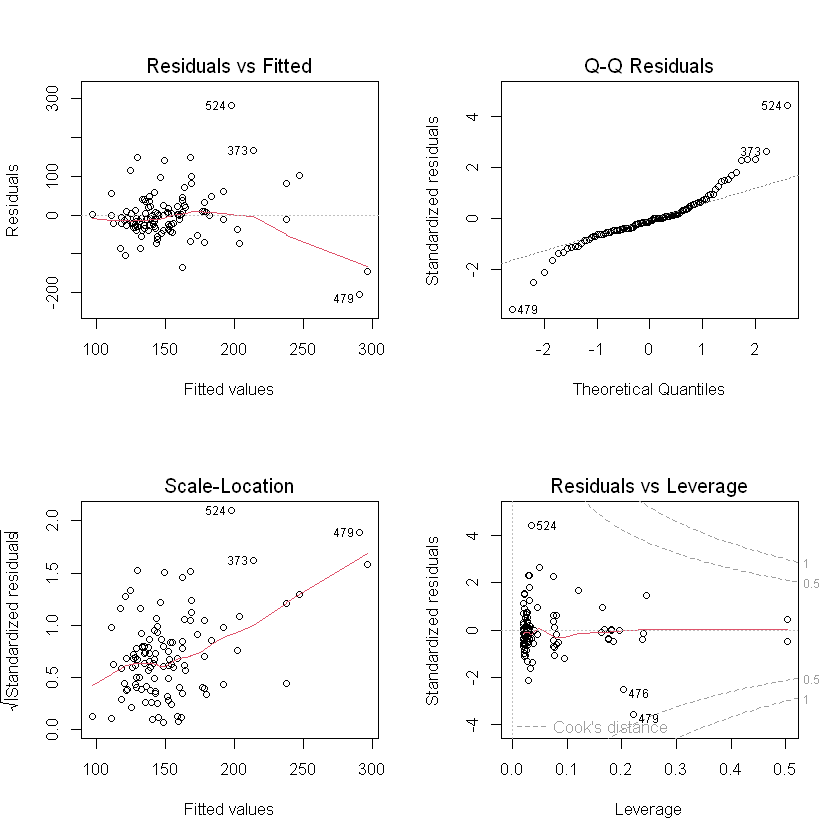

In [103]:
par(mfrow = c(2, 2))
plot(fit_full)
par(mfrow = c(1, 1))

In [8]:
r <- rstandard(fit_full)
f <- fitted(fit_full)
ord <- order(abs(r), decreasing = TRUE)
head(data.frame(row = ord, fitted = f[ord], rstd = r[ord]), 10)
cd <- cooks.distance(fit_full)
head(sort(cd, decreasing = TRUE), 10)

,row,fitted,rstd
,<int>,<dbl>,<dbl>
524,96,197.5669,4.412272
479,84,290.7921,-3.562595
373,72,213.3665,2.622875
476,82,296.1222,-2.511648
254,48,129.8541,2.323387
22,9,167.7043,2.295400
136,28,148.7713,2.254246
556,101,162.1084,-2.119063
418,76,124.6242,1.782469


479        476        524         35        136         10        373 
0.40181127 0.17835963 0.07841588 0.07581533 0.04616014 0.04237016 0.03972365 
       121        302         83 
0.02445955 0.02445955 0.01966998

In [9]:
fit1  <- lm(log(LoanAmount)~ Gender + Dependents + log(ApplicantIncome) + log(Credit_History) + Married , data = df1) 
summary(fit1)


Call:
lm(formula = log(LoanAmount) ~ Gender + Dependents + log(ApplicantIncome) + 
    log(Credit_History) + Married, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.78837 -0.17189  0.04033  0.21082  0.94128 

Coefficients: (1 not defined because of singularities)
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           1.738233   0.948573   1.832   0.0698 .  
GenderFemale          0.211812   0.497385   0.426   0.6711    
GenderMale            0.074596   0.453955   0.164   0.8698    
Dependents1           0.002924   0.320549   0.009   0.9927    
Dependents2           0.041012   0.318462   0.129   0.8978    
Dependents3+          0.042012   0.334880   0.125   0.9004    
log(ApplicantIncome)  0.395582   0.076851   5.147 1.29e-06 ***
log(Credit_History)         NA         NA      NA       NA    
MarriedNo            -0.289289   0.571215  -0.506   0.6136    
MarriedYes           -0.173929   0.540955  -0.322   0.7485    
---
Signif. code

Warning message:
"not plotting observations with leverage one:
  23, 61"


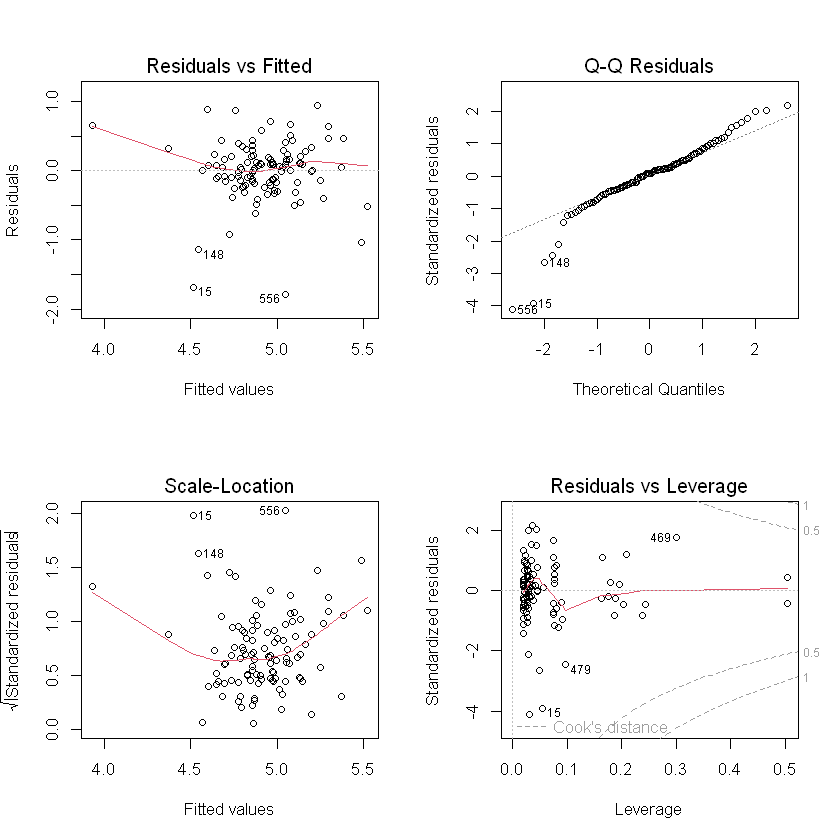

In [10]:
par(mfrow=c(2,2)); plot(fit1); par(mfrow=c(1,1))

In [11]:
df1$Gender <- trimws(as.character(df1$Gender))
df1$Gender[df1$Gender == ""] <- NA
df1 <- df1[!is.na(df1$Gender), ]


In [12]:
set.seed(1)
idx <- sample(seq_len(nrow(df1)), size = floor(0.8 * nrow(df1)))
train <- df1[idx, ]
test  <- df1[-idx, ]
fit <- lm(LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = train)
pred <- predict(fit, newdata = test)
rmse <- sqrt(mean((test$LoanAmount - pred)^2))
rmse

[1] 71.49844

In [17]:
mm <- model.matrix(
  ~ Gender + Dependents + ApplicantIncome + Credit_History + Married,
  data = train
)

# Check rank
qr(mm)$rank
ncol(mm)

# Find exact linear dependencies
lc <- caret::findLinearCombos(mm)
lc

# If something is flagged, show the bad columns
if (!is.null(lc$remove)) {
  colnames(mm)[lc$remove]
}
table(train$Credit_History, useNA = "ifany")
summary(train$Credit_History)
unique(train$Credit_History)
# compare with full data too
table(df1$Credit_History, useNA = "ifany")

[1] 8

[1] 9

$linearCombos
$linearCombos[[1]]
[1] 7 1


$remove
[1] 7

[1] "Credit_History"


 1 
88 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       1       1       1       1       1 

[1] 1


  1 
110 

In [ ]:
#K-fold 
library(caret)
set.seed(1)
ctrl <- trainControl(
  method = "cv",
  number = 10
)

fit_cv <- train(
  LoanAmount ~ Gender + Dependents + ApplicantIncome + CoapplicantIncome + Married,
  data = df1,
  method = "lm",
  trControl = ctrl,
  metric = "RMSE"
)

fit_cv

Warning message in predict.lm(modelFit, newdata):
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


Linear Regression 

111 samples
  6 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 100, 100, 100, 99, 99, 100, ... 
Resampling results:

  RMSE      Rsquared   MAE     
  54.80546  0.5383671  39.47653

Tuning parameter 'intercept' was held constant at a value of TRUE

In [25]:
# fit subset selection
aa=LoanAmount ~ Gender + Dependents + ApplicantIncome + CoapplicantIncome + Married
fitt1 <- regsubsets(aa,data = df1,nvmax = 5)
# summary of model selection stats
fit_sum <- summary(fitt1)
fit_sum$adjr2
fit_sum$cp
fit_sum$bic

[1] 0.2949795 0.4494186 0.4451411 0.4427059 0.4379343

[1] 24.6191758 -3.1558196 -1.3149227  0.1768682  2.0804860

[1] -30.39230 -54.15080 -49.61481 -45.46143 -40.85769

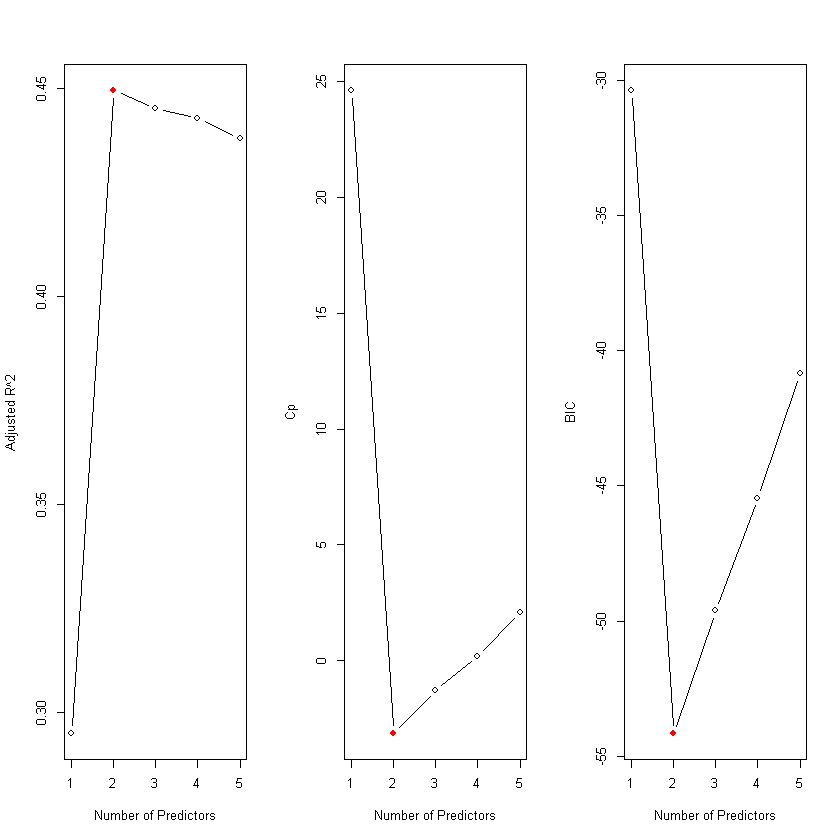

In [26]:
par(mfrow = c(1, 3))
plot(fit_sum$adjr2, type = "b", xlab = "Number of Predictors", ylab = "Adjusted R^2")
points(which.max(fit_sum$adjr2), max(fit_sum$adjr2), col = "red", pch = 19)
plot(fit_sum$cp, type = "b", xlab = "Number of Predictors", ylab = "Cp")
points(which.min(fit_sum$cp), min(fit_sum$cp), col = "red", pch = 19)
plot(fit_sum$bic, type = "b", xlab = "Number of Predictors", ylab = "BIC")
points(which.min(fit_sum$bic), min(fit_sum$bic), col = "red", pch = 19)

In [33]:
best_fit <- regsubsets(
  LoanAmount ~ Gender + Dependents + ApplicantIncome + CoapplicantIncome + Married,
  data = train,
  nvmax = 5
)
best_sum <- summary(best_fit)
best_id <- which.min(best_sum$bic)

In [34]:
step_both <- step(
  lm(LoanAmount ~ 1, data = train),
  scope = list(
    lower = LoanAmount ~ 1,
    upper = LoanAmount ~ Gender + Dependents + ApplicantIncome + CoapplicantIncome + Married
  ),
  direction = "both",
  trace = 0
)
predict.regsubsets <- function(object, newdata, id, ...) {
  form <- as.formula(object$call[[2]])
  mat <- model.matrix(form, newdata)
  coefi <- coef(object, id = id)
  xvars <- names(coefi)
  mat[, xvars] %*% coefi
}

In [36]:
pred_best <- predict.regsubsets(best_fit, test, id = best_id)
pred_step <- predict(step_both, newdata = test)
# RMSE
rmse_best <- sqrt(mean((test$LoanAmount - pred_best)^2))
rmse_step <- sqrt(mean((test$LoanAmount - pred_step)^2))
# Results
formula(step_both)
coef(best_fit, id = best_id)
rmse_best
rmse_step

LoanAmount ~ ApplicantIncome + CoapplicantIncome

(Intercept)   ApplicantIncome CoapplicantIncome 
      57.12834644        0.01425737        0.01382956

[1] 62.00847

[1] 62.00847

In [37]:
# Results
coef(best_fit, id = best_id)
formula(step_both)
rmse_best
rmse_step

(Intercept)   ApplicantIncome CoapplicantIncome 
      57.12834644        0.01425737        0.01382956

LoanAmount ~ ApplicantIncome + CoapplicantIncome

[1] 62.00847

[1] 62.00847

In [59]:
full_data <- rbind(train, test)
full_x <- model.matrix(
  LoanAmount ~ Gender + Dependents + ApplicantIncome + CoapplicantIncome + Married,
  data = full_data
)[, -1]
x_train <- full_x[1:nrow(train), , drop = FALSE]
x_test  <- full_x[(nrow(train) + 1):nrow(full_x), , drop = FALSE]
y_train <- train$LoanAmount
y_test  <- test$LoanAmount

In [60]:
ncol(x_train)
ncol(x_test)

colnames(x_train)
colnames(x_test)

setdiff(colnames(x_train), colnames(x_test))
setdiff(colnames(x_test), colnames(x_train))

[1] 8

[1] 8

[1] "GenderMale"        "Dependents1"       "Dependents2"      
[4] "Dependents3+"      "ApplicantIncome"   "CoapplicantIncome"
[7] "MarriedNo"         "MarriedYes"

[1] "GenderMale"        "Dependents1"       "Dependents2"      
[4] "Dependents3+"      "ApplicantIncome"   "CoapplicantIncome"
[7] "MarriedNo"         "MarriedYes"

character(0)

character(0)

In [61]:
set.seed(5703)
cv_ridge <- cv.glmnet(
  x_train, y_train,
  alpha = 0,
  nfolds = 5,
  family = "gaussian",
  type.measure = "mse"
)


In [62]:
cv_lasso <- cv.glmnet(
  x_train, y_train,
  alpha = 1,
  nfolds = 5,
  family = "gaussian",
  type.measure = "mse"
)

In [63]:
pred_ridge <- predict(cv_ridge, newx = x_test, s = "lambda.min")
pred_lasso <- predict(cv_lasso, newx = x_test, s = "lambda.min")
# Test RMSE
rmse_ridge <- sqrt(mean((y_test - pred_ridge)^2))
rmse_lasso <- sqrt(mean((y_test - pred_lasso)^2))
# Chosen lambdas
cv_ridge$lambda.min
cv_lasso$lambda.min
# Coefficients at selected lambda
coef(cv_ridge, s = "lambda.min")
coef(cv_lasso, s = "lambda.min")
rmse_ridge
rmse_lasso

[1] 27.85344

[1] 11.77989

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       71.622895148
GenderMale        18.888658015
Dependents1        1.338946929
Dependents2       -1.540315691
Dependents3+       1.757166173
ApplicantIncome    0.010160054
CoapplicantIncome  0.009974445
MarriedNo         -5.555430684
MarriedYes        -4.407606778

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       89.524032268
GenderMale         .          
Dependents1        .          
Dependents2        .          
Dependents3+       .          
ApplicantIncome    0.009589266
CoapplicantIncome  0.009218928
MarriedNo          .          
MarriedYes         .          

[1] 56.71309

[1] 54.9969

In [64]:
coef(cv_ridge, s = "lambda.min")
coef(cv_lasso, s = "lambda.min")
coef(cv_ridge, s = "lambda.1se")
coef(cv_lasso, s = "lambda.1se")

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       71.622895148
GenderMale        18.888658015
Dependents1        1.338946929
Dependents2       -1.540315691
Dependents3+       1.757166173
ApplicantIncome    0.010160054
CoapplicantIncome  0.009974445
MarriedNo         -5.555430684
MarriedYes        -4.407606778

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       89.524032268
GenderMale         .          
Dependents1        .          
Dependents2        .          
Dependents3+       .          
ApplicantIncome    0.009589266
CoapplicantIncome  0.009218928
MarriedNo          .          
MarriedYes         .          

9 x 1 sparse Matrix of class "dgCMatrix"
                     lambda.1se
(Intercept)       115.543807524
GenderMale         11.509280913
Dependents1        -2.308395546
Dependents2         1.338199070
Dependents3+        2.990273631
ApplicantIncome     0.004254720
CoapplicantIncome   0.004182224
MarriedNo          -0.356062632
MarriedYes         -0.612744292

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.1se
(Intercept)       1.472713e+02
GenderMale        .           
Dependents1       .           
Dependents2       .           
Dependents3+      .           
ApplicantIncome   1.268091e-03
CoapplicantIncome 1.000201e-03
MarriedNo         .           
MarriedYes        .           

9 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       89.524032268
GenderMale         .          
Dependents1        .          
Dependents2        .          
Dependents3+       .          
ApplicantIncome    0.009589266
CoapplicantIncome  0.009218928
MarriedNo          .          
MarriedYes         .          

3 x 1 sparse Matrix of class "dgCMatrix"
                    lambda.min
(Intercept)       89.524032268
ApplicantIncome    0.009589266
CoapplicantIncome  0.009218928

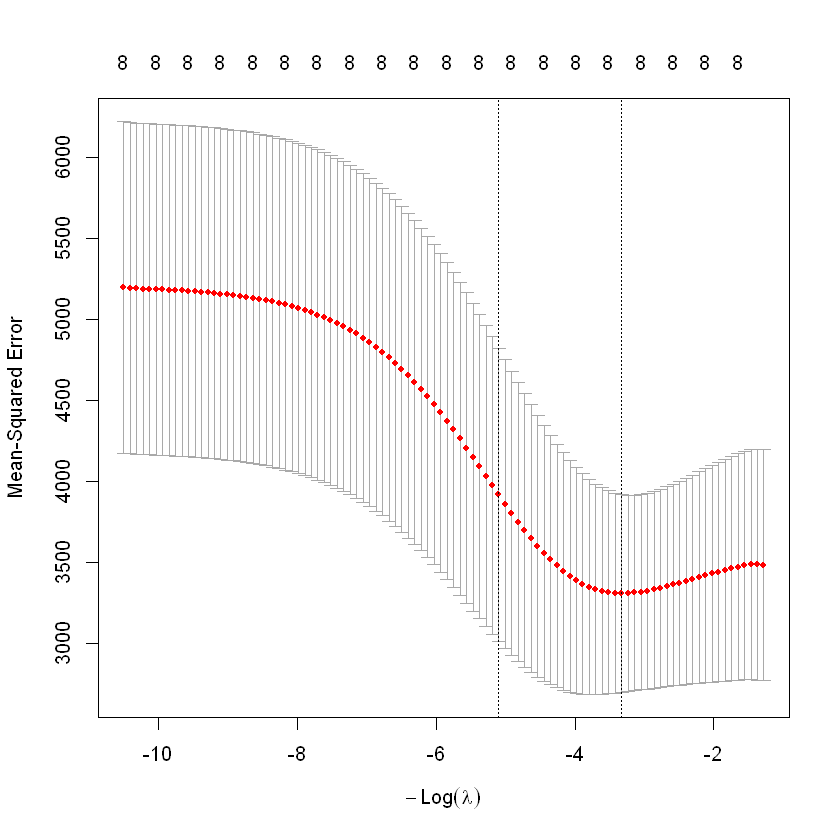

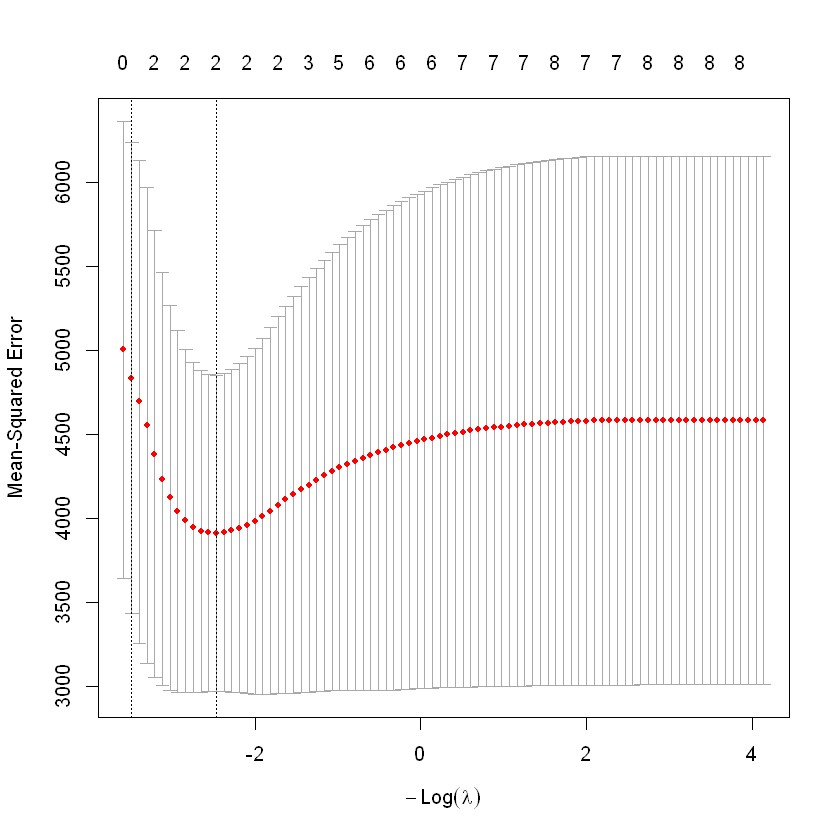

In [65]:
lasso_coef <- coef(cv_lasso, s = "lambda.min")
lasso_coef
lasso_coef[lasso_coef[,1] != 0, , drop = FALSE]
plot(cv_ridge)
plot(cv_lasso)

In [66]:
train$Loan_Status <- factor(train$Loan_Status, levels = c("No", "Yes"))
test$Loan_Status  <- factor(test$Loan_Status,  levels = c("No", "Yes"))
# Build one combined model matrix first so train/test have identical columns
full_data <- rbind(train, test)
full_x <- model.matrix(
  Loan_Status ~ Gender + Dependents + ApplicantIncome +
    CoapplicantIncome + Married,
  data = full_data
)[, -1]
x_train <- full_x[1:nrow(train), , drop = FALSE]
x_test  <- full_x[(nrow(train) + 1):nrow(full_x), , drop = FALSE]
# glmnet binomial response can be a 0/1 vector
y_train <- ifelse(train$Loan_Status == "Yes", 1, 0)
y_test  <- ifelse(test$Loan_Status  == "Yes", 1, 0)
set.seed(123)
# LASSO logistic regression with 5-fold CV
cv_lasso_logit <- cv.glmnet(
  x_train, y_train,
  alpha = 1,
  family = "binomial",
  nfolds = 5,
  type.measure = "deviance"
)
# CV plot
plot(cv_lasso_logit)
# Selected lambda
cv_lasso_logit$lambda.min
cv_lasso_logit$lambda.1se
# Coefficients at chosen lambda
coef(cv_lasso_logit, s = "lambda.min")
# Predicted probabilities for ROC/AUC
prob_test <- as.numeric(
  predict(cv_lasso_logit, newx = x_test, s = "lambda.min", type = "response")
)

# Convert probabilities to class predictions using 0.5 cutoff
pred_class <- ifelse(prob_test >= 0.5, "Yes", "No")
pred_class <- factor(pred_class, levels = c("No", "Yes"))
# Confusion matrix with positive class = "Yes"
cm <- confusionMatrix(pred_class, test$Loan_Status, positive = "Yes")
cm
# Pull key metrics
cm$byClass["Sensitivity"]
cm$byClass["Specificity"]
# ROC and AUC
roc_obj <- roc(response = test$Loan_Status, predictor = prob_test, levels = c("No", "Yes"))
plot(roc_obj)
auc(roc_obj)

ERROR: Error in `contrasts<-`(`*tmp*`, value = contr.funs[1 + isOF[nn]]): contrasts can be applied only to factors with 2 or more levels
